# Modelos predictivos del flujo bentónico

Este notebook plantea un enfoque de **regresión** para predecir el valor numérico de `flux_O2` a partir de variables hidrodinámicas y de series temporales.

**Escenario**: se excluyen todas las variables derivadas del sensor de O2 (mean_O2 y features tsfresh O2__*), para evaluar si es posible reproducir/predecir el flujo cuando falla este sensor, utilizando únicamente variables hidrodinámicas (velocidades, presión, oleaje, temperatura).

> **Nota**: tras la limpieza global (NB3), se eliminaron las ventanas con flujo acumulado positivo, por lo que todas las ventanas restantes corresponden a consumo neto de oxígeno.

In [16]:
## IMPORTS
import os

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_PATH = '/content/drive/MyDrive/TFM_NoeliaGarciaGarcia/Pipeline'
else:
    BASE_PATH = os.path.abspath(os.path.join(os.path.dirname('__file__'), '..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_regression, mutual_info_classif

# Regresión
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.svm import SVR
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    mean_absolute_percentage_error
)

# Clasificación
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score,
    confusion_matrix, classification_report
)

pd.set_option("display.max_columns", None)

print(f"Entorno: {'Colab' if IN_COLAB else 'Local'}")
print(f"BASE_PATH: {BASE_PATH}")

Entorno: Local
BASE_PATH: g:\Mi unidad\TFM_NoeliaGarciaGarcia\TFM_OxygenFlux\Pipeline


# CARGA DE DATOS

In [17]:
base_path = os.path.join(BASE_PATH, "DATA", "PROCESSED")
df = pd.read_csv(os.path.join(base_path, "df_classified.csv"))

print(f"Filas: {len(df)}, Columnas: {len(df.columns)}")
print(f"\nEstadísticas del flujo:")
print(df["flux_O2"].describe())

Filas: 568, Columnas: 146

Estadísticas del flujo:
count    568.000000
mean     -13.021226
std       17.936533
min     -186.763730
25%      -13.633024
50%       -8.317158
75%       -5.489255
max       -0.717503
Name: flux_O2, dtype: float64


# PREPARACIÓN DE FEATURES

Se excluyen:
- Variables derivadas directas del flujo (target leak): `flux_O2`, `accumulated_flux_O2`, `flux_smooth`, `optimal_shift_*`, `valid_flux_window`, `flux_status`, `flag_flux_positivo`
- **Todas las variables del sensor de O2** (`mean_O2`, `O2__*`): se simula un escenario en el que el sensor de oxígeno falla y se quiere predecir el flujo solo con variables hidrodinámicas.
- `flag_outlier_global`, `flag_outlier_window`, `flag_vel_baja`, `flag_vz_baja` → flags de QC basados en velocidades/presión/O2

Se mantienen como features:
- `hour`, `day`, `hour_int` → ciclo diurno (fotosíntesis vs respiración)
- `oleaje_clase` → clasificación de oleaje (derivada de presión/velocidades, no del O2)
- Variables de oleaje, velocidad, presión, temperatura y sus features tsfresh

In [18]:
# Columnas a excluir:
# - target y derivadas directas del flujo (fuga de información)
# - variables del sensor O2 (escenario: sensor O2 no disponible)
# - flags de calidad (requieren O2 o flujo procesado para calcularse)
# - identificadores y strings sin valor predictivo
cols_excluir = [
    # Identificadores
    "window_id",
    # Target y derivadas del flujo
    "flux_O2", "accumulated_flux_O2", "flux_smooth",
    "optimal_shift_samples", "optimal_shift_sec", "optimal_shift_day",
    "valid_flux_window", "flux_status",
    # Sensor O2 (simular fallo del sensor)
    "mean_O2",
    # Flags de calidad (dependen de O2 o del flujo procesado → no disponibles sin sensor)
    "flag_outlier_window",   # detecta spikes en señal O2
    "flag_outlier_global",   # detecta anomalías en el flujo calculado
    "flag_flux_positivo",    # signo del flujo
    "flag_vel_baja",         # se mantendría en principio, pero se excluye por consistencia
    # Redundantes o strings
    "oleaje_clase_nombre",
    "cluster_kmeans",
]

# Excluir todas las features tsfresh de O2
cols_excluir_o2 = [c for c in df.columns if c.startswith("O2__")]

# Excluir cualquier columna de tipo string/object
cols_excluir_str = [c for c in df.columns if df[c].dtype == "object"]

cols_excluir = cols_excluir + cols_excluir_o2 + cols_excluir_str

# Construir lista de features (solo numéricas)
feature_cols = [c for c in df.columns if c not in cols_excluir]

print(f"Features disponibles: {len(feature_cols)}")
print(f"Columnas O2 excluidas: {len(cols_excluir_o2)}")
print(f"Columnas string excluidas: {cols_excluir_str}")
print(f"Primeras 20: {feature_cols[:20]}")

Features disponibles: 111
Columnas O2 excluidas: 19
Columnas string excluidas: ['flux_status', 'oleaje_clase_Wiberg_nombre', 'oleaje_clase_SIMAR_nombre']
Primeras 20: ['hour', 'day', 'mean_vx', 'mean_vy', 'mean_vz', 'mean_speed', 'mean_temp', 'mean_pres', 'std_pres', 'Oleaje', 'Mod_orbital', 'STD_orbital', 'hour_int', 'Oleaje_SIMAR', 'vz__mean', 'vz__median', 'vz__standard_deviation', 'vz__variance', 'vz__minimum', 'vz__maximum']


In [19]:
# Filtrar ventanas válidas con flujo no nulo
mask = df["flux_O2"].notna()
if "valid_flux_window" in df.columns:
    mask = mask & (df["valid_flux_window"] == True)

df_valid = df.loc[mask].copy()
print(f"Ventanas válidas para modelado: {len(df_valid)}")

Ventanas válidas para modelado: 568


---
# PARTE 1: REGRESIÓN

Predecir el valor numérico de `flux_O2` (mmol/m²/día).

In [20]:
# Target de regresión
X_reg = df_valid[feature_cols].copy()
y_reg = df_valid["flux_O2"].copy()

# Ordenar cronológicamente antes de dividir
sort_idx = df_valid["hour"].sort_values().index
X_reg = X_reg.loc[sort_idx]
y_reg = y_reg.loc[sort_idx]

# Split cronológico: 80% inicial → entrenamiento, 20% final → test
# Al ser una serie temporal, no se mezclan datos futuros en el entrenamiento.
n_train = int(len(X_reg) * 0.8)
X_train_r = X_reg.iloc[:n_train]
X_test_r = X_reg.iloc[n_train:]
y_train_r = y_reg.iloc[:n_train]
y_test_r = y_reg.iloc[n_train:]

print(f"Train: {X_train_r.shape} (horas {df_valid.loc[X_train_r.index, 'hour'].min():.1f}–{df_valid.loc[X_train_r.index, 'hour'].max():.1f})")
print(f"Test:  {X_test_r.shape} (horas {df_valid.loc[X_test_r.index, 'hour'].min():.1f}–{df_valid.loc[X_test_r.index, 'hour'].max():.1f})")

Train: (454, 111) (horas 13.1–143.4)
Test:  (114, 111) (horas 143.6–177.6)


In [21]:
# Filtro de colinealidad (único filtro de selección)
corr_abs = X_train_r.corr(numeric_only=True).abs()
upper = corr_abs.where(np.triu(np.ones(corr_abs.shape), k=1).astype(bool))
cols_drop_corr = [c for c in upper.columns if (upper[c] > 0.95).any()]

X_train_rf = X_train_r.drop(columns=cols_drop_corr, errors="ignore")
X_test_rf = X_test_r.drop(columns=cols_drop_corr, errors="ignore")

# Usar TODAS las features restantes (sin límite de top-k)
selected_features_reg = X_train_rf.columns.tolist()
X_train_sel_r = X_train_rf.copy()
X_test_sel_r = X_test_rf.copy()

# MI ranking (solo informativo, no se usa para filtrar)
X_train_imp_rf = X_train_rf.fillna(X_train_rf.median(numeric_only=True))
mi_reg = mutual_info_regression(X_train_imp_rf, y_train_r, random_state=42)
mi_reg_s = pd.Series(mi_reg, index=X_train_rf.columns).sort_values(ascending=False)

print(f"Features tras filtro colinealidad: {X_train_rf.shape[1]}")
print(f"Features usadas para el modelo: {len(selected_features_reg)} (todas)")
print(f"\nTop 15 por información mutua (ranking informativo):")
display(mi_reg_s.head(15).to_frame("mutual_info"))

Features tras filtro colinealidad: 51
Features usadas para el modelo: 51 (todas)

Top 15 por información mutua (ranking informativo):


,mutual_info
vz__standard_deviation,0.174424
Oleaje_SIMAR,0.146077
temp__standard_deviation,0.141015
Oleaje,0.139090
vy__absolute_maximum,0.115526
hour,0.101311
vx__variance,0.101111
vx__minimum,0.100134
vx__mean_abs_change,0.100077
temp__variance,0.097706


## Diagnóstico de la selección de features
¿Qué variables se eliminaron por colinealidad? ¿Cuáles quedaron fuera del top-30? ¿Hay variables de presión entre las seleccionadas?

In [22]:
# ============================================================
# DIAGNÓSTICO: qué pasó con cada variable
# ============================================================

# 1. Variables eliminadas por colinealidad (r > 0.95)
print(f"{'='*60}")
print(f"VARIABLES ELIMINADAS POR COLINEALIDAD ({len(cols_drop_corr)})")
print(f"{'='*60}")
for col in sorted(cols_drop_corr):
    # Buscar con qué variable tiene correlación > 0.95
    if col in corr_abs.columns:
        high_corr = corr_abs[col][corr_abs[col] > 0.95].drop(col, errors="ignore")
        if not high_corr.empty:
            partner = high_corr.idxmax()
            r_val = high_corr.max()
            print(f"  {col:40s} → r={r_val:.3f} con {partner}")
        else:
            print(f"  {col}")
    else:
        print(f"  {col}")

# 2. Variables de presión: ¿dónde quedaron?
print(f"\n{'='*60}")
print(f"VARIABLES DE PRESIÓN — DIAGNÓSTICO")
print(f"{'='*60}")
pres_cols = [c for c in feature_cols if "pres" in c.lower()]
for col in pres_cols:
    eliminada_colin = col in cols_drop_corr
    if not eliminada_colin and col in mi_reg_s.index:
        rank = list(mi_reg_s.index).index(col) + 1
        mi_val = mi_reg_s[col]
        en_top30 = col in selected_features_reg
        print(f"  {col:40s} → MI={mi_val:.4f} (rank {rank}/53) {'✅ en top-30' if en_top30 else '❌ fuera del top-30'}")
    elif eliminada_colin:
        # Buscar con qué correlaciona
        if col in corr_abs.columns:
            high_corr = corr_abs[col][corr_abs[col] > 0.95].drop(col, errors="ignore")
            partner = high_corr.idxmax() if not high_corr.empty else "?"
            r_val = high_corr.max() if not high_corr.empty else 0
            print(f"  {col:40s} → ❌ ELIMINADA por colinealidad (r={r_val:.3f} con {partner})")
        else:
            print(f"  {col:40s} → ❌ ELIMINADA por colinealidad")
    else:
        print(f"  {col:40s} → no encontrada en MI ranking")

# 3. Resumen: categorías de variables en el top-30
print(f"\n{'='*60}")
print(f"COMPOSICIÓN DEL TOP-30 SELECCIONADO")
print(f"{'='*60}")
categorias = {"oleaje": 0, "velocidad": 0, "presión": 0, "temperatura": 0, "temporal": 0, "otro": 0}
for feat in selected_features_reg:
    f_lower = feat.lower()
    if "oleaje" in f_lower or "simar" in f_lower or "orbital" in f_lower:
        categorias["oleaje"] += 1
    elif "vx" in f_lower or "vy" in f_lower or "vz" in f_lower:
        categorias["velocidad"] += 1
    elif "pres" in f_lower:
        categorias["presión"] += 1
    elif "temp" in f_lower:
        categorias["temperatura"] += 1
    elif "hour" in f_lower or "day" in f_lower:
        categorias["temporal"] += 1
    else:
        categorias["otro"] += 1

for cat, n in categorias.items():
    print(f"  {cat:15s}: {n} variables")
print(f"  {'TOTAL':15s}: {sum(categorias.values())}")

VARIABLES ELIMINADAS POR COLINEALIDAD (60)
  Mod_orbital                              → r=0.997 con Oleaje
  STD_orbital                              → r=0.996 con Mod_orbital
  day                                      → r=1.000 con hour
  hour_int                                 → r=1.000 con hour
  pres__absolute_maximum                   → r=1.000 con pres__maximum
  pres__maximum                            → r=1.000 con pres__absolute_maximum
  pres__mean                               → r=1.000 con pres__sum_values
  pres__median                             → r=1.000 con pres__root_mean_square
  pres__minimum                            → r=0.999 con pres__quantile__q_0.01
  pres__quantile__q_0.01                   → r=1.000 con pres__quantile__q_0.05
  pres__quantile__q_0.05                   → r=1.000 con pres__quantile__q_0.01
  pres__quantile__q_0.25                   → r=1.000 con pres__sum_values
  pres__quantile__q_0.75                   → r=1.000 con pres__root_mean_square
 

In [23]:
# Modelos de regresión
modelos_reg = {
    "Linear Regression": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("reg", LinearRegression())
    ]),
    "Ridge": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("reg", Ridge(alpha=1.0))
    ]),
    "Random Forest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("reg", RandomForestRegressor(
            n_estimators=500,
            max_depth=10,
            min_samples_leaf=3,
            random_state=42,
            n_jobs=-1
        ))
    ]),
    "Gradient Boosting": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("reg", GradientBoostingRegressor(
            n_estimators=300,
            max_depth=5,
            learning_rate=0.05,
            random_state=42
        ))
    ]),
}

preds_reg = {}

for nombre, modelo in modelos_reg.items():
    modelo.fit(X_train_sel_r, y_train_r)
    preds_reg[nombre] = modelo.predict(X_test_sel_r)

print("Modelos de regresión entrenados:", list(modelos_reg.keys()))

Modelos de regresión entrenados: ['Linear Regression', 'Ridge', 'Random Forest', 'Gradient Boosting']


In [24]:
# Evaluación de regresión
resumen_reg = []
for nombre, y_pred in preds_reg.items():
    mae = mean_absolute_error(y_test_r, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_r, y_pred))
    r2 = r2_score(y_test_r, y_pred)
    # Error porcentual medio (evitando divisiones por 0)
    mask_nonzero = y_test_r.abs() > 0.01
    if mask_nonzero.sum() > 0:
        mape = (((y_test_r[mask_nonzero] - y_pred[mask_nonzero]) / y_test_r[mask_nonzero]).abs().mean()) * 100
    else:
        mape = np.nan

    resumen_reg.append({
        "modelo": nombre,
        "MAE": mae,
        "RMSE": rmse,
        "R²": r2,
        "MAPE (%)": mape
    })

df_resumen_reg = pd.DataFrame(resumen_reg).sort_values("R²", ascending=False)
display(df_resumen_reg)

mejor_reg = df_resumen_reg.iloc[0]["modelo"]
print(f"\nMejor modelo de regresión: {mejor_reg}")

,modelo,MAE,RMSE,R²,MAPE (%)
2,Random Forest,8.654789,11.594207,0.355286,85.895773
1,Ridge,8.591720,13.189847,0.165618,69.784633
0,Linear Regression,9.041023,13.938044,0.068272,70.911358
3,Gradient Boosting,10.118804,15.401327,-0.137631,95.517701



Mejor modelo de regresión: Random Forest


## Gráficas: valor real vs predicho

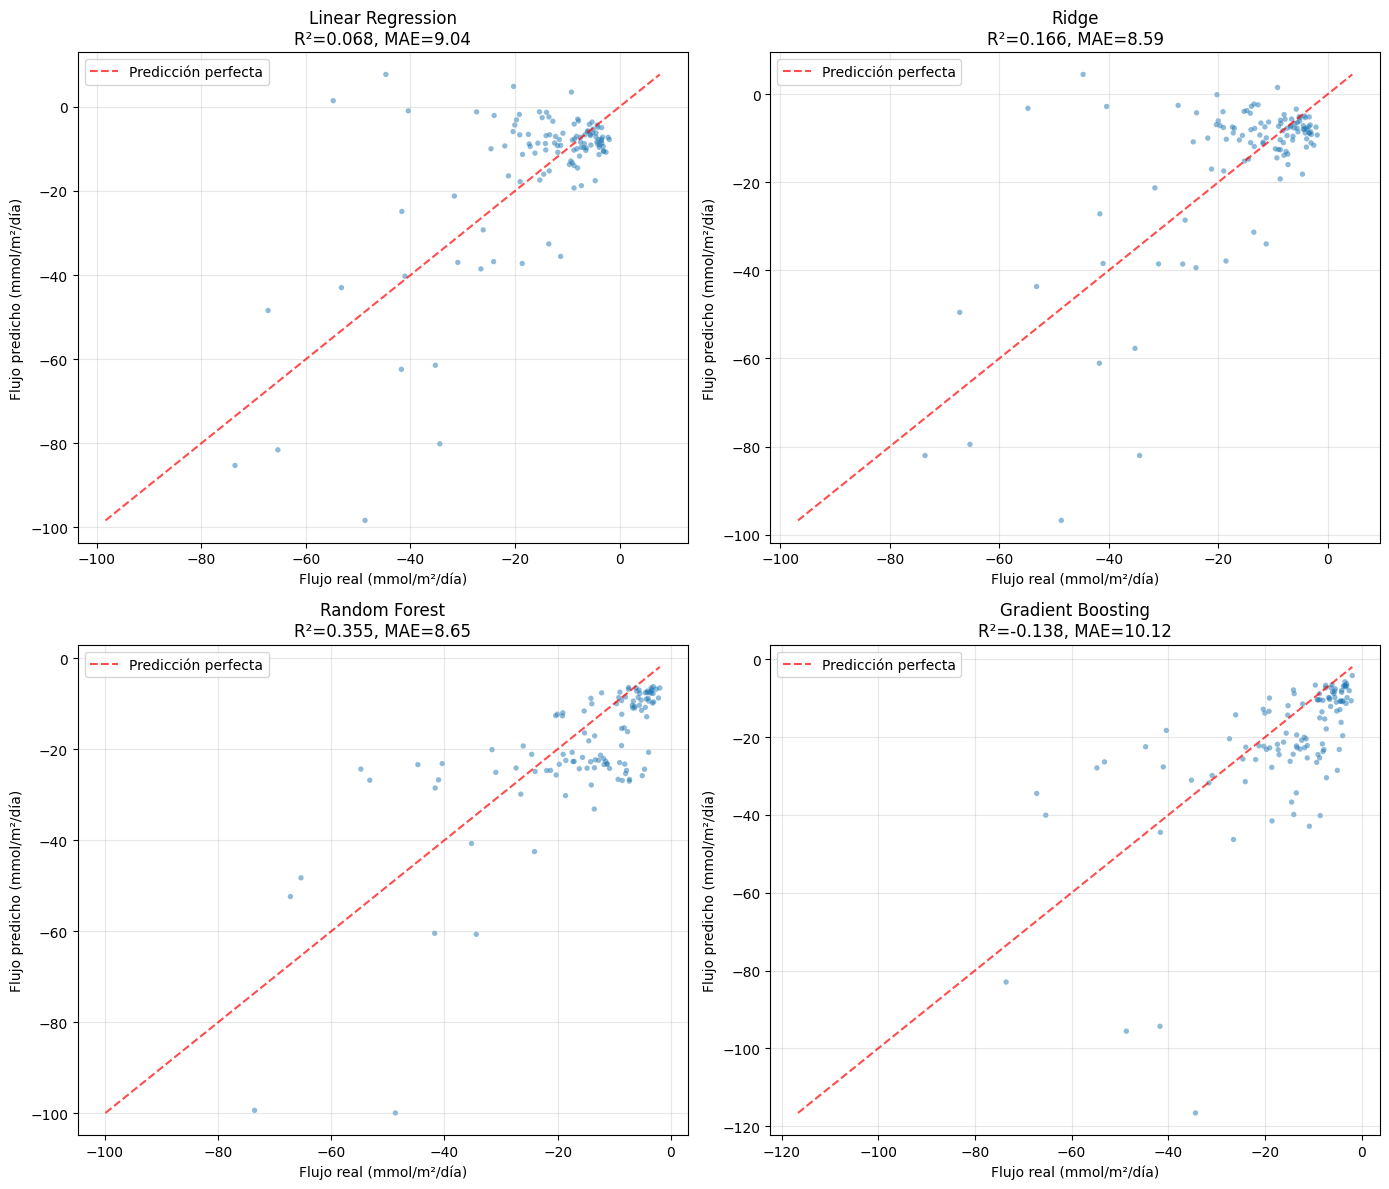

In [25]:
# Scatter: real vs predicho para cada modelo
out_dir = os.path.join(BASE_PATH, "..", "Memoria", "tex", "img")
os.makedirs(out_dir, exist_ok=True)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for idx, (nombre, y_pred) in enumerate(preds_reg.items()):
    ax = axes[idx]
    ax.scatter(y_test_r, y_pred, alpha=0.5, s=15, edgecolor="none")

    # Línea perfecta
    lims = [min(y_test_r.min(), y_pred.min()), max(y_test_r.max(), y_pred.max())]
    ax.plot(lims, lims, "r--", alpha=0.7, label="Predicción perfecta")

    r2 = r2_score(y_test_r, y_pred)
    mae = mean_absolute_error(y_test_r, y_pred)
    ax.set_xlabel("Flujo real (mmol/m²/día)")
    ax.set_ylabel("Flujo predicho (mmol/m²/día)")
    ax.set_title(f"{nombre}\nR²={r2:.3f}, MAE={mae:.2f}")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

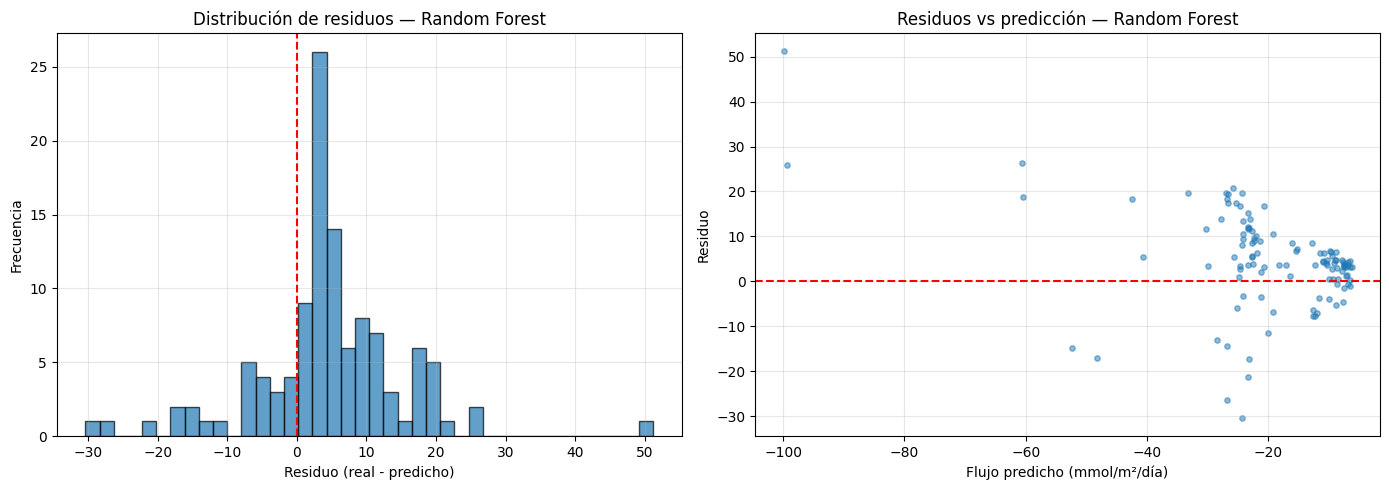

Residuo medio: 4.5263
Residuo std:   10.6742


In [26]:
# Residuos del mejor modelo
y_pred_best = preds_reg[mejor_reg]
residuos = y_test_r.values - y_pred_best

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma de residuos
axes[0].hist(residuos, bins=40, edgecolor="black", alpha=0.7)
axes[0].axvline(0, color="red", linestyle="--")
axes[0].set_xlabel("Residuo (real - predicho)")
axes[0].set_ylabel("Frecuencia")
axes[0].set_title(f"Distribución de residuos — {mejor_reg}")
axes[0].grid(True, alpha=0.3)

# Residuos vs valor predicho
axes[1].scatter(y_pred_best, residuos, alpha=0.5, s=15)
axes[1].axhline(0, color="red", linestyle="--")
axes[1].set_xlabel("Flujo predicho (mmol/m²/día)")
axes[1].set_ylabel("Residuo")
axes[1].set_title(f"Residuos vs predicción — {mejor_reg}")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Residuo medio: {residuos.mean():.4f}")
print(f"Residuo std:   {residuos.std():.4f}")

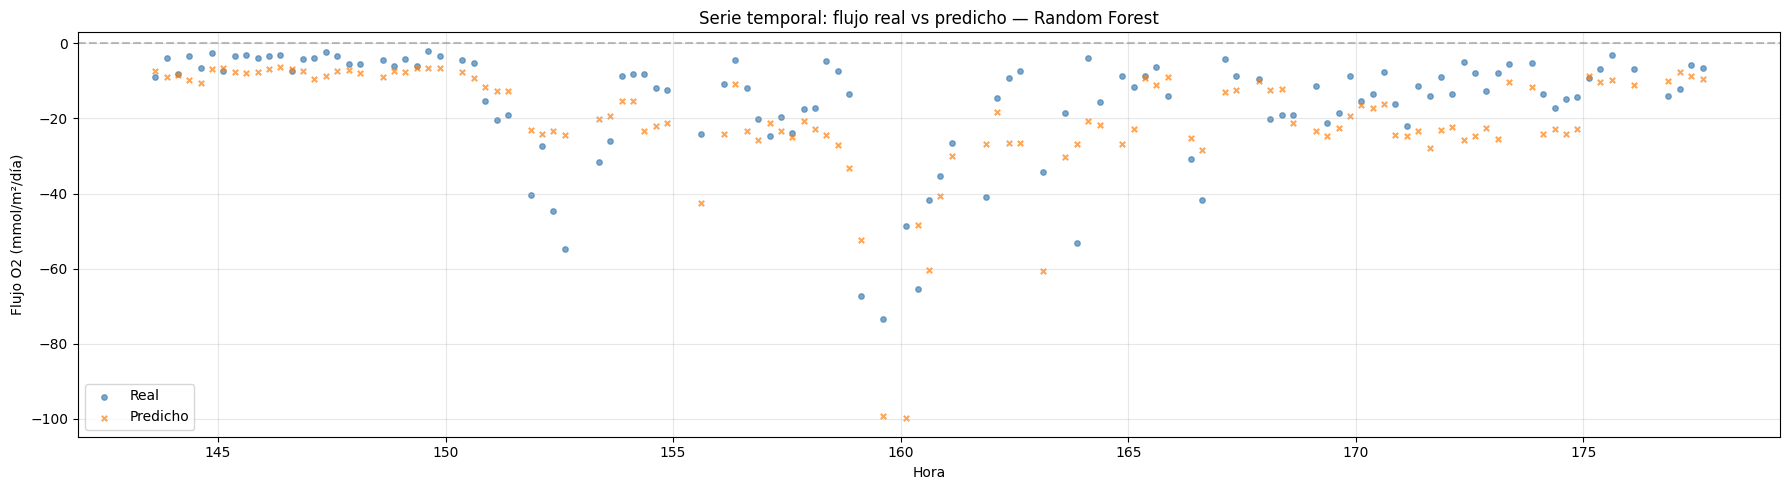

In [27]:
# Serie temporal: real vs predicho (mejor modelo)
df_test_reg = df_valid.loc[X_test_r.index, ["hour"]].copy()
df_test_reg["flux_real"] = y_test_r.values
df_test_reg["flux_pred"] = y_pred_best
df_test_reg = df_test_reg.sort_values("hour")

plt.figure(figsize=(18, 5))
plt.scatter(df_test_reg["hour"], df_test_reg["flux_real"], s=15, alpha=0.7, label="Real", color="steelblue")
plt.scatter(df_test_reg["hour"], df_test_reg["flux_pred"], s=15, alpha=0.7, label="Predicho", color="tab:orange", marker="x")
plt.axhline(0, color="gray", linestyle="--", alpha=0.5)
plt.xlabel("Hora")
plt.ylabel("Flujo O2 (mmol/m²/día)")
plt.title(f"Serie temporal: flujo real vs predicho — {mejor_reg}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

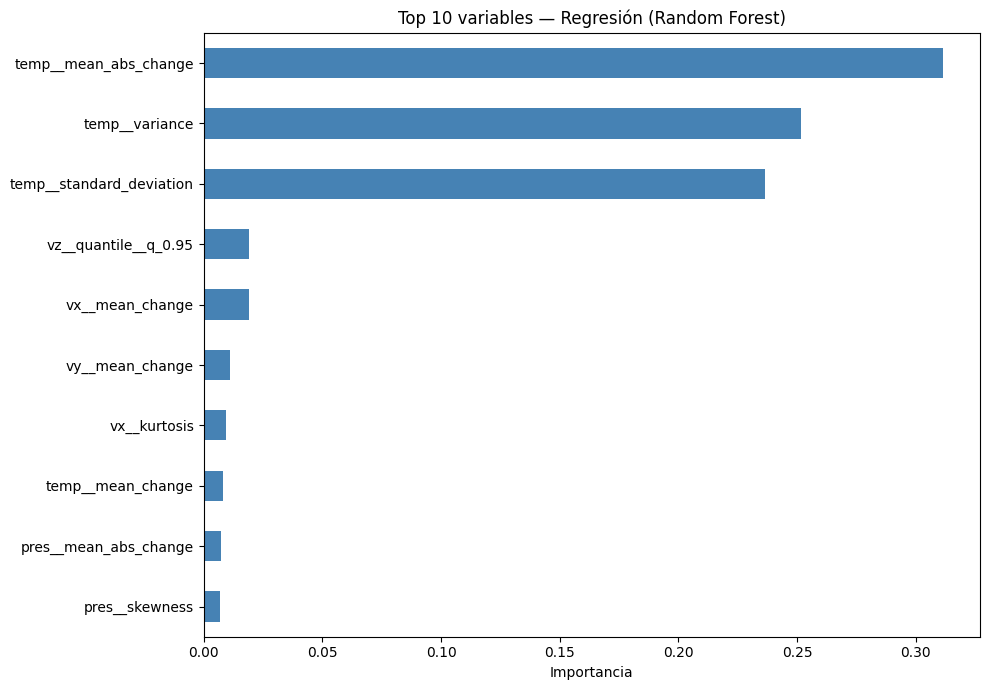

,importancia
temp__mean_abs_change,0.311543
temp__variance,0.251536
temp__standard_deviation,0.236418
vz__quantile__q_0.95,0.019126
vx__mean_change,0.018941
vy__mean_change,0.011139
vx__kurtosis,0.009229
temp__mean_change,0.008006
pres__mean_abs_change,0.007482
pres__skewness,0.007067


In [28]:
# Importancia de variables (si el mejor es RF o GB)
if mejor_reg in ["Random Forest", "Gradient Boosting"]:
    importancias_reg = pd.Series(
        modelos_reg[mejor_reg].named_steps["reg"].feature_importances_,
        index=selected_features_reg
    ).sort_values(ascending=False)

    top_n = min(10, len(importancias_reg))
    fig_reg_imp = plt.figure(figsize=(10, 7))
    importancias_reg.head(top_n).sort_values().plot(kind="barh", color="steelblue")
    plt.title(f"Top {top_n} variables — Regresión ({mejor_reg})")
    plt.xlabel("Importancia")
    plt.tight_layout()
    plt.show()

    display(importancias_reg.head(top_n).to_frame("importancia"))

---
# RESUMEN

Tabla final con los resultados de regresión.

In [29]:
print("=" * 60)
print("RESUMEN FINAL — REGRESIÓN")
print("=" * 60)

display(df_resumen_reg)

print(f"\nMejor modelo: {mejor_reg} (R² = {df_resumen_reg.iloc[0]['R²']:.4f})")

RESUMEN FINAL — REGRESIÓN


,modelo,MAE,RMSE,R²,MAPE (%)
2,Random Forest,8.654789,11.594207,0.355286,85.895773
1,Ridge,8.591720,13.189847,0.165618,69.784633
0,Linear Regression,9.041023,13.938044,0.068272,70.911358
3,Gradient Boosting,10.118804,15.401327,-0.137631,95.517701



Mejor modelo: Random Forest (R² = 0.3553)


## Error de regresión por estado de oleaje
¿El modelo predice igual de bien en calma que en oleaje intenso? Se calcula MAE y RMSE del mejor regresor por cluster SIMAR.

ERROR DE REGRESIÓN POR CLUSTER — Random Forest


,n,MAE,RMSE,error_medio,flujo_std_real
oleaje_clase_SIMAR,,,,,
1,23,3.2824,3.7589,3.0105,1.8897
2,50,10.5497,13.6175,8.5429,16.0998
3,41,9.3577,11.8195,0.4784,13.8661



Figura guardada: mae_por_cluster.png


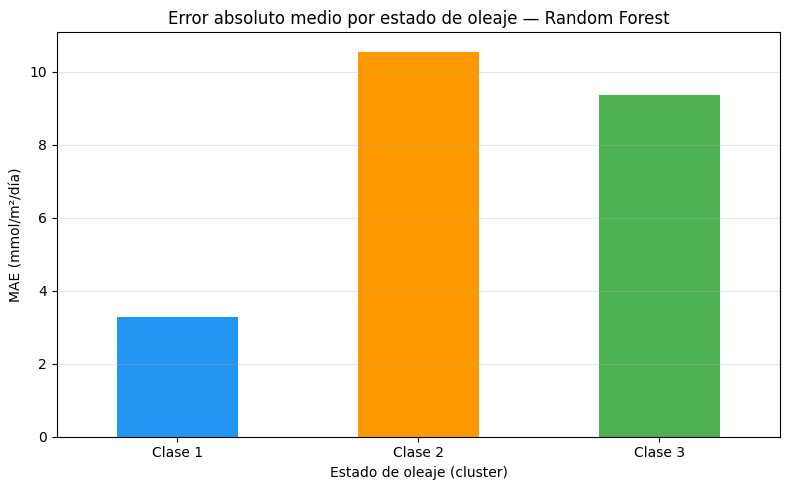

In [30]:
# ============================================================
# ERROR DE REGRESIÓN POR ESTADO DE OLEAJE (mejor modelo)
# ============================================================

# Recuperar cluster SIMAR para las ventanas de test
col_clase = "oleaje_clase_SIMAR"
if col_clase not in df_valid.columns:
    col_clase = "oleaje_clase_Wiberg"

y_pred_best = preds_reg[mejor_reg]
df_error = df_valid.loc[X_test_r.index, [col_clase]].copy()
df_error["flux_real"] = y_test_r.values
df_error["flux_pred"] = y_pred_best
df_error["error_abs"] = (df_error["flux_real"] - df_error["flux_pred"]).abs()
df_error["error"] = df_error["flux_real"] - df_error["flux_pred"]

# Métricas por cluster
resumen_error = df_error.groupby(col_clase).agg(
    n=("error_abs", "count"),
    MAE=("error_abs", "mean"),
    RMSE=("error", lambda x: np.sqrt((x**2).mean())),
    error_medio=("error", "mean"),
    flujo_std_real=("flux_real", "std"),
).round(4)

print(f"ERROR DE REGRESIÓN POR CLUSTER — {mejor_reg}")
print(f"{'='*60}")
display(resumen_error)

# Gráfica: MAE por cluster
fig, ax = plt.subplots(figsize=(8, 5))
resumen_error["MAE"].plot(kind="bar", ax=ax, color=["#2196F3", "#FF9800", "#4CAF50", "#E91E63"][:len(resumen_error)])
ax.set_xlabel("Estado de oleaje (cluster)")
ax.set_ylabel("MAE (mmol/m²/día)")
ax.set_title(f"Error absoluto medio por estado de oleaje — {mejor_reg}")
ax.set_xticklabels([f"Clase {int(i)}" for i in resumen_error.index], rotation=0)
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
fig.savefig(os.path.join(out_dir, "mae_por_cluster.png"), dpi=150, bbox_inches="tight")
print(f"\nFigura guardada: mae_por_cluster.png")
plt.show()